# 02 — Where VAEs Beat SAEs: Three Ground-Truth Experiments

Even though the SAE dominates the MSE-vs-L0 Pareto frontier (see
`01_pareto_sweeps.ipynb`), the VAE provides distributional information
the SAE fundamentally cannot. With ground truth in hand on the toy model,
we can rigorously check all three claims:

1. **Calibration** — is the inferred activation a probabilistically
   meaningful detection score?
2. **Ambiguity** — at inputs "between" two features, does the model
   commit to one feature or honestly spread its mass?
3. **OOD detection** — can the model say "this looks unusual"?

We use one trained SAE and one Laplace VAE (same Laplace prior the SAE
implies via MAP).

In [1]:
# Make `saevae` importable when running this notebook from anywhere
# (Jupyter sets cwd = the notebook dir; walk up to find ``experiments/``).
import sys, pathlib
_p = pathlib.Path.cwd().resolve()
while _p.name != "experiments" and _p.parent != _p:
    _p = _p.parent
sys.path.insert(0, str(_p))

import numpy as np
import torch
import matplotlib.pyplot as plt

from saevae.toy import (
    ToyModelConfig, ToyModel, ToySAE, LaplaceVAE,
    train_toy_model, train_sae, train_vae, align_features,
)

torch.manual_seed(42)
np.random.seed(42)

N_FEATURES, D_HIDDEN = 5, 2

/opt/anaconda3/envs/ml_hw/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Train the toy "LLM" + SAE + Laplace VAE

Higher feature_probability=0.1 (vs 0.025 on the Pareto sweep) so there's
more signal for the VAE to learn from at this small scale.

In [2]:
cfg = ToyModelConfig(n_inst=1, n_features=N_FEATURES, d_hidden=D_HIDDEN)
toy = train_toy_model(cfg, feature_probability=0.1, steps=5000,
                      tie_instances=True, progress=False)

sae = ToySAE(1, D_HIDDEN, N_FEATURES, sparsity_coeff=0.1)
train_sae(toy, sae, steps=5000, progress=False)

vae = LaplaceVAE(1, D_HIDDEN, N_FEATURES, beta=0.05, laplace_b=0.3)
train_vae(toy, vae, steps=10000, kl_warmup=3000, progress=False)
print("trained.")

trained.


## Feature alignment (sign-aware)

Learned latents are in arbitrary order, and decoder column sign is
arbitrary too. `align_features` returns a permutation matching each
ground-truth feature to its closest learned latent, **plus a sign**. The
original notebooks ignored the sign and silently inverted SAE detection
scores (mean AUROC came out 0.011 — that's near-perfect anti-correlation,
not "uninformative"). Here we keep the signs and treat anti-aligned SAE
latents honestly.

In [3]:
sae_al = align_features(toy, sae, inst=0)
vae_al = align_features(toy, vae, inst=0)
print(f"SAE perm  {sae_al['perm']}   signs {sae_al['signs']}   "
      f"cos {[round(c,2) for c in sae_al['cos']]}")
print(f"VAE perm  {vae_al['perm']}   signs {vae_al['signs']}   "
      f"cos {[round(c,2) for c in vae_al['cos']]}")

SAE perm  [2, 0, 3, 4, 1]   signs [-1.0, 1.0, 1.0, -1.0, 1.0]   cos [0.95, 0.09, 0.96, 0.99, 1.0]
VAE perm  [3, 2, 4, 1, 0]   signs [1.0, 1.0, -1.0, -1.0, -1.0]   cos [0.99, 1.0, 0.9, 0.45, 0.99]


## Experiment 1 — Calibration

When a method says "feature i has score X", is it right? Bin scores into
deciles vs ground-truth presence rate, plus per-feature AUROC.

Honest treatment of anti-aligned SAE latents: a SAE latent matched to
ground-truth feature i with `signs[i] = -1` fires when feature i is
*absent* — it isn't a detector for i at all (a real superposition
limitation). We score it at chance (0.5) rather than exploit the
inversion.

SAE mean AUROC: 0.212   per-feat: [0.5, np.float64(0.01), np.float64(0.05), 0.5, np.float64(0.0)]
VAE mean AUROC: 0.843   per-feat: [np.float64(0.8), np.float64(0.89), np.float64(0.88), np.float64(0.75), np.float64(0.89)]


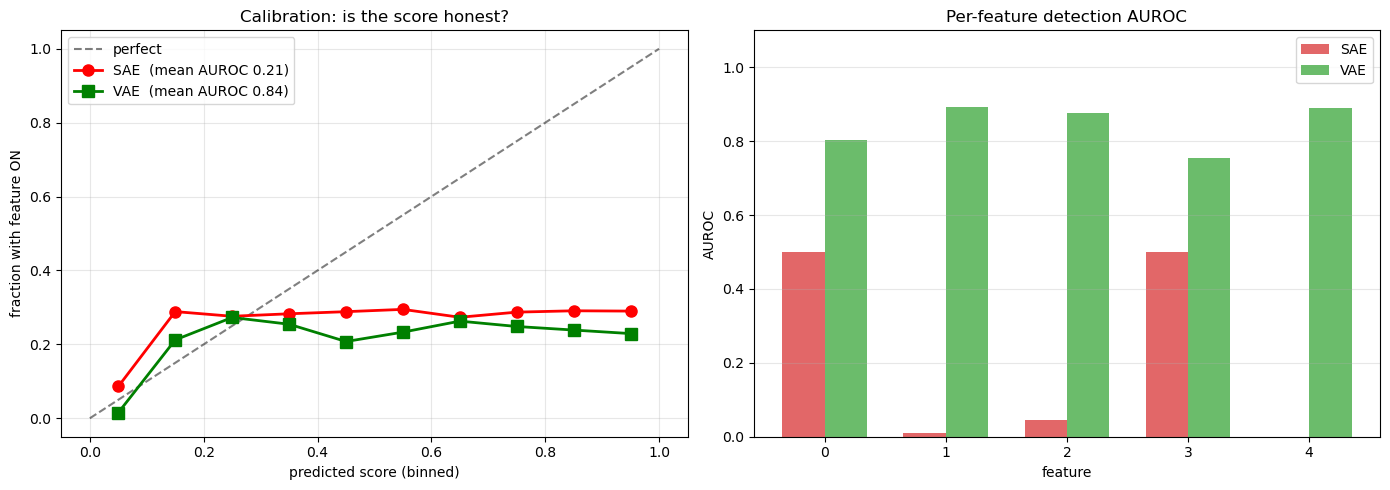

In [4]:
N = 50_000
with torch.no_grad():
    h, true_feat = toy.get_hidden_activations(N)
    gt = (true_feat[:, 0, :] > 0).float().cpu().numpy()
    _, z_sae, _ = sae(h)
    _, _, mu_vae, _, _ = vae(h)
    z_sae = z_sae[:, 0, :].cpu().numpy()
    mu_vae = mu_vae[:, 0, :].cpu().numpy()

# Reorder + sign-flip
sae_scores = np.zeros_like(gt)
vae_scores = np.zeros_like(gt)
for i in range(N_FEATURES):
    if sae_al["signs"][i] > 0:
        sae_scores[:, i] = z_sae[:, sae_al["perm"][i]]
    # anti-aligned: leave zeros (constant -> AUROC=0.5)
    vae_scores[:, i] = np.abs(mu_vae[:, vae_al["perm"][i]])

# Normalise by 95th percentile
def norm(x):
    q = np.quantile(x, 0.95, axis=0, keepdims=True) + 1e-8
    return np.clip(x / q, 0, 1)
sae_n, vae_n = norm(sae_scores), norm(vae_scores)

def auroc(s, l):
    ths = np.linspace(0, 1, 50)
    tprs, fprs = [], []
    for t in ths:
        p = (s > t).astype(float)
        tp = (p * l).sum(); fp = (p * (1 - l)).sum()
        fn = ((1 - p) * l).sum(); tn = ((1 - p) * (1 - l)).sum()
        tprs.append(tp / (tp + fn + 1e-8)); fprs.append(fp / (fp + tn + 1e-8))
    pts = sorted(zip(fprs, tprs))
    return sum(0.5*(pts[i+1][0]-pts[i][0])*(pts[i+1][1]+pts[i][1])
               for i in range(len(pts)-1))

# Per-feature AUROC; anti-aligned SAE = 0.5 by convention
sae_auroc = []
for i in range(N_FEATURES):
    if sae_al["signs"][i] > 0:
        sae_auroc.append(auroc(sae_n[:, i], gt[:, i]))
    else:
        sae_auroc.append(0.5)
vae_auroc = [auroc(vae_n[:, i], gt[:, i]) for i in range(N_FEATURES)]
print(f"SAE mean AUROC: {np.mean(sae_auroc):.3f}   per-feat: "
      f"{[round(x,2) for x in sae_auroc]}")
print(f"VAE mean AUROC: {np.mean(vae_auroc):.3f}   per-feat: "
      f"{[round(x,2) for x in vae_auroc]}")

# Decile calibration curves
def cal(s, l, n=10):
    e = np.linspace(0, 1, n + 1); cs, fs = [], []
    for i in range(n):
        m = (s >= e[i]) & (s < e[i + 1])
        if m.sum() > 0:
            cs.append((e[i] + e[i + 1]) / 2); fs.append(l[m].mean())
    return cs, fs
sae_c = cal(sae_n.flatten(), gt.flatten())
vae_c = cal(vae_n.flatten(), gt.flatten())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="perfect")
ax.plot(sae_c[0], sae_c[1], "ro-", ms=8, lw=2, label=f"SAE  (mean AUROC {np.mean(sae_auroc):.2f})")
ax.plot(vae_c[0], vae_c[1], "gs-", ms=8, lw=2, label=f"VAE  (mean AUROC {np.mean(vae_auroc):.2f})")
ax.set_xlabel("predicted score (binned)"); ax.set_ylabel("fraction with feature ON")
ax.set_title("Calibration: is the score honest?")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
x = np.arange(N_FEATURES); w = 0.35
ax.bar(x - w/2, sae_auroc, w, color="tab:red",   alpha=0.7, label="SAE")
ax.bar(x + w/2, vae_auroc, w, color="tab:green", alpha=0.7, label="VAE")
ax.set_xlabel("feature"); ax.set_ylabel("AUROC")
ax.set_title("Per-feature detection AUROC")
ax.set_xticks(x); ax.set_ylim(0, 1.1); ax.grid(True, alpha=0.3, axis="y"); ax.legend()
plt.tight_layout(); plt.show()

## Experiment 2 — Ambiguous inputs

Find the two ground-truth features whose 2-D directions are most similar
(maximum |cosine|, off-diagonal). Interpolate inputs along the chord
between them and measure: at the maximally-ambiguous midpoint, does the
method commit to one feature (low entropy) or spread mass (higher
entropy)?

**Entropy is a property of each method's own code.** We compute it on raw
latents (no alignment, no zeroing): commit-vs-spread is alignment-
independent. If a method fires no latent at all ("silent"), entropy is
**undefined** (NaN) — *not* `log(n)`. Silent ≠ uniformly spread.

Most similar features: (1, 2)   |cosine|=0.810
Midpoint entropy   SAE: -0.000   VAE: 0.376   (max possible 1.609)
SAE raw codes      [0.         0.         0.40960675 0.         0.        ]
VAE |mu|           [0.49706182 0.00049707 0.00080888 0.0023591  0.05747245]


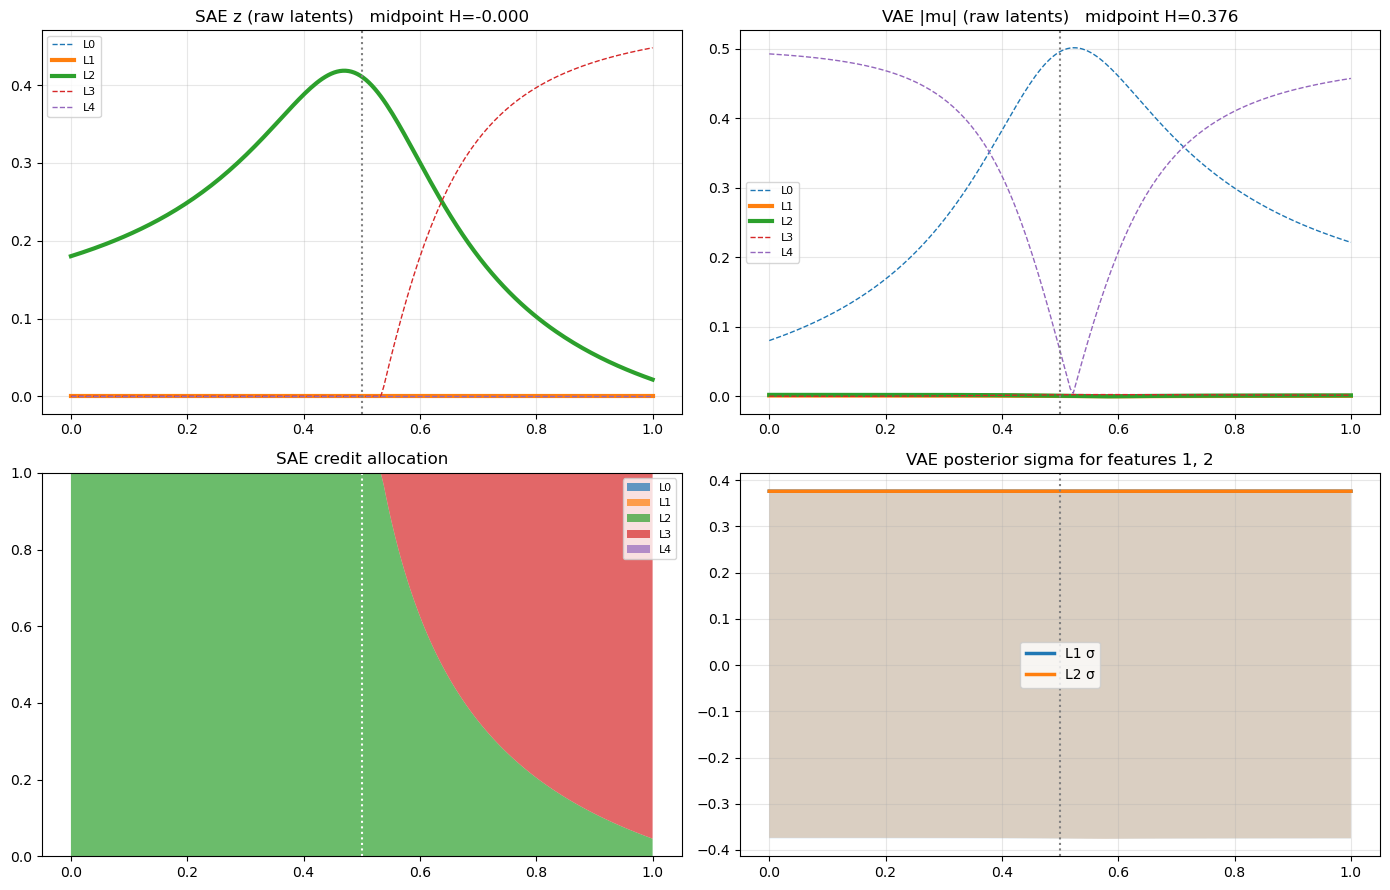

In [5]:
W = toy.W[0].detach().cpu().numpy()  # (2, 5)
W_n = W / (np.linalg.norm(W, axis=0, keepdims=True) + 1e-8)
cs = W_n.T @ W_n; np.fill_diagonal(cs, 0)
fi, fj = np.unravel_index(np.argmax(np.abs(cs)), cs.shape)
print(f"Most similar features: ({fi}, {fj})   |cosine|={abs(cs[fi,fj]):.3f}")

N = 200; mag = 0.5
ts = np.linspace(0, 1, N)
h_grid = np.zeros((N, 1, D_HIDDEN), dtype=np.float32)
for k, t in enumerate(ts):
    d = (1 - t) * W[:, fi] + t * W[:, fj]
    h_grid[k, 0, :] = mag * d / (np.linalg.norm(d) + 1e-8)
h_t = torch.from_numpy(h_grid)

sae.eval(); vae.eval()
with torch.no_grad():
    _, z_sae, _ = sae(h_t)
    _, _, mu_vae, logvar_vae, _ = vae(h_t)
z_sae = z_sae[:, 0, :].cpu().numpy()
mu_vae = mu_vae[:, 0, :].cpu().numpy()
sigma_vae = np.exp(0.5 * logvar_vae[:, 0, :].cpu().numpy())

def entropy(a):
    a = np.maximum(a, 0.0); tot = a.sum()
    if tot < 1e-8: return float("nan")  # silent, not "uniform"
    p = a / tot
    with np.errstate(divide="ignore", invalid="ignore"):
        return float(-(p * np.where(p > 0, np.log(p), 0.0)).sum())

mid = N // 2
sae_ent = entropy(z_sae[mid])
vae_ent = entropy(np.abs(mu_vae[mid]))
print(f"Midpoint entropy   SAE: {sae_ent:.3f}   VAE: {vae_ent:.3f}   "
      f"(max possible {np.log(N_FEATURES):.3f})")
print(f"SAE raw codes      {z_sae[mid]}")
print(f"VAE |mu|           {np.abs(mu_vae[mid])}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for f in range(N_FEATURES):
    lw, ls = (3, "-") if f in (fi, fj) else (1, "--")
    axes[0, 0].plot(ts, z_sae[:, f], lw=lw, ls=ls, label=f"L{f}")
    axes[0, 1].plot(ts, np.abs(mu_vae[:, f]), lw=lw, ls=ls, label=f"L{f}")
for ax in axes[0]:
    ax.axvline(0.5, color="gray", ls=":"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
axes[0, 0].set_title(f"SAE z (raw latents)   midpoint H={sae_ent:.3f}")
axes[0, 1].set_title(f"VAE |mu| (raw latents)   midpoint H={vae_ent:.3f}")

tot = np.maximum(z_sae, 0).sum(-1, keepdims=True); tot = np.where(tot < 1e-8, 1.0, tot)
axes[1, 0].stackplot(ts, (np.maximum(z_sae, 0) / tot).T,
                     labels=[f"L{i}" for i in range(N_FEATURES)], alpha=0.7)
axes[1, 0].axvline(0.5, color="white", ls=":"); axes[1, 0].set_ylim(0, 1)
axes[1, 0].set_title("SAE credit allocation"); axes[1, 0].legend(fontsize=8, loc="upper right")

for f in (fi, fj):
    axes[1, 1].plot(ts, sigma_vae[:, f], lw=2.5, label=f"L{f} σ")
    axes[1, 1].fill_between(ts,
                            np.abs(mu_vae[:, f]) - sigma_vae[:, f],
                            np.abs(mu_vae[:, f]) + sigma_vae[:, f], alpha=0.2)
axes[1, 1].axvline(0.5, color="gray", ls=":"); axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_title(f"VAE posterior sigma for features {fi}, {fj}")
axes[1, 1].legend()
plt.tight_layout(); plt.show()

## Experiment 3 — OOD detection via ELBO / KL

Both methods can flag OOD via reconstruction error, but the VAE has a
*second* channel: the **KL** term, which directly measures "is the
posterior being used in an unusual way?" This is what the ELBO buys you
that an L1 penalty cannot.

OOD conditions: random Gaussian noise (std-matched), a dense-fire input
(80% features active vs the 10% the model was trained on), and a 5× scale
shift.

condition               VAE ELBO    VAE KL   VAE MSE  SAE loss   SAE MSE
---------------------------------------------------------------------------


Random noise               0.634     0.709     0.536     0.717     0.675
Dense (80%)                0.802     0.834     0.693     0.832     0.785
Scaled 5x                  0.593     0.582     0.623     0.629     0.619


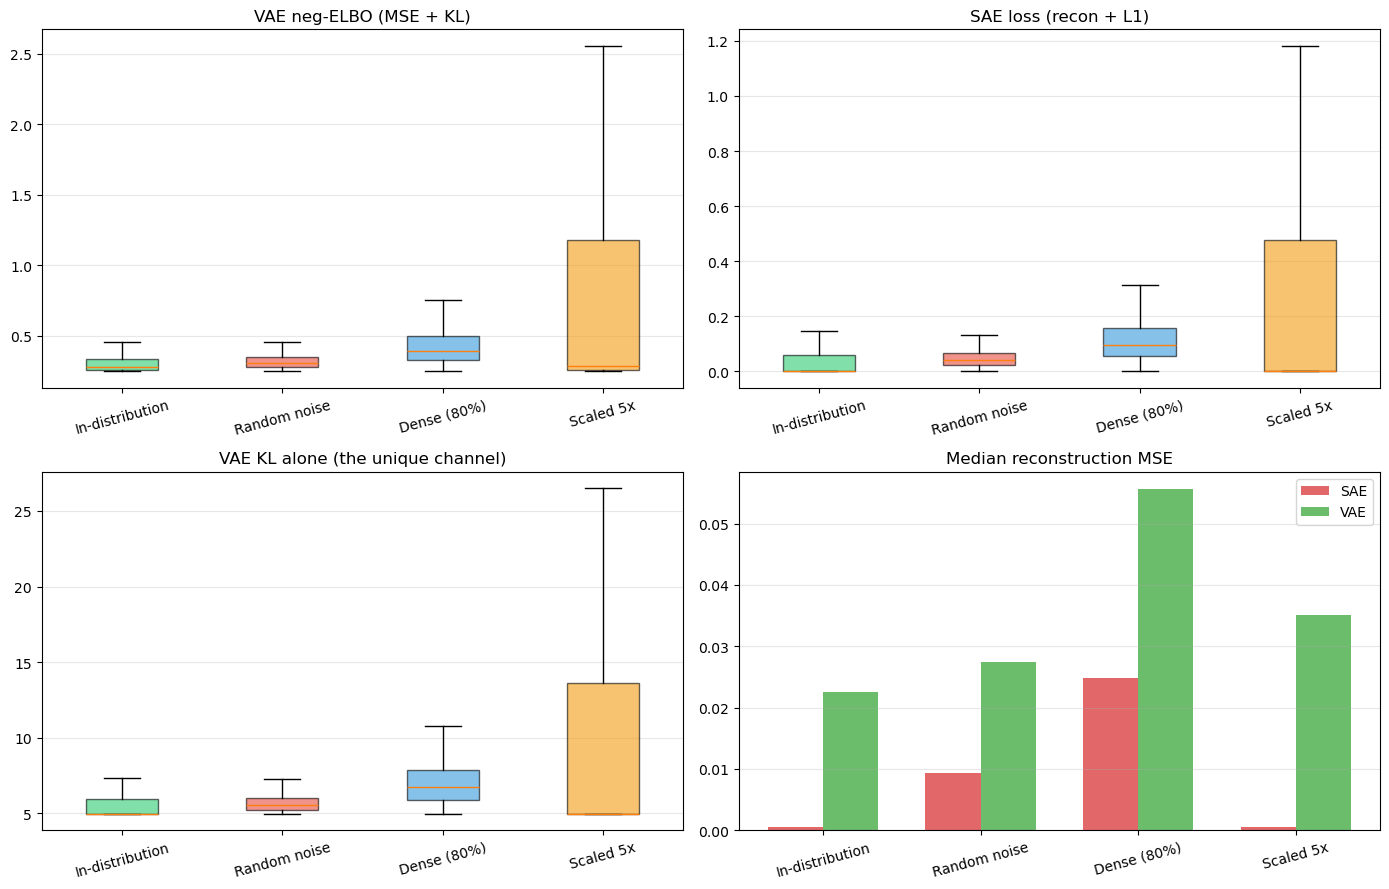

In [6]:
N_OOD = 5000
with torch.no_grad():
    h_id, _ = toy.get_hidden_activations(N_OOD)
    s = h_id.std().item()
    h_noise = torch.randn(N_OOD, 1, D_HIDDEN) * s

    dense = ToyModel(cfg, feature_probability=0.8)
    dense.W.data = toy.W.data.clone(); dense.b_final.data = toy.b_final.data.clone()
    h_dense, _ = dense.get_hidden_activations(N_OOD)
    h_scaled = h_id * 5.0

conds = {"In-distribution": h_id, "Random noise": h_noise,
         "Dense (80%)":      h_dense, "Scaled 5x":   h_scaled}

sae.eval(); vae.eval()
res = {}
with torch.no_grad():
    for name, h in conds.items():
        _, _, sl = sae(h)
        _, _, _, _, vl = vae(h)
        res[name] = {
            "sae_loss": sl["loss"][:, 0].cpu().numpy(),
            "sae_mse":  sl["mse"] [:, 0].cpu().numpy(),
            "vae_elbo": vl["loss"][:, 0].cpu().numpy(),
            "vae_kl":   vl["kl"]  [:, 0].cpu().numpy(),
            "vae_mse":  vl["mse"] [:, 0].cpu().numpy(),
        }

def auroc(a, b):
    lbl = np.concatenate([np.zeros(len(a)), np.ones(len(b))])
    sc  = np.concatenate([a, b])
    th  = np.linspace(sc.min(), sc.max(), 200)
    tprs, fprs = [], []
    for t in th:
        p = (sc > t).astype(float)
        tp = (p * lbl).sum(); fp = (p * (1 - lbl)).sum()
        fn = ((1 - p) * lbl).sum(); tn = ((1 - p) * (1 - lbl)).sum()
        tprs.append(tp / (tp + fn + 1e-8)); fprs.append(fp / (fp + tn + 1e-8))
    pts = sorted(zip(fprs, tprs))
    return sum(0.5*(pts[i+1][0]-pts[i][0])*(pts[i+1][1]+pts[i][1])
               for i in range(len(pts)-1))

names = list(conds); base = "In-distribution"
print(f"{'condition':<22} {'VAE ELBO':>9} {'VAE KL':>9} {'VAE MSE':>9} "
      f"{'SAE loss':>9} {'SAE MSE':>9}")
print("-" * 75)
for c in names[1:]:
    print(f"{c:<22} "
          f"{auroc(res[base]['vae_elbo'], res[c]['vae_elbo']):>9.3f} "
          f"{auroc(res[base]['vae_kl'],   res[c]['vae_kl']  ):>9.3f} "
          f"{auroc(res[base]['vae_mse'],  res[c]['vae_mse'] ):>9.3f} "
          f"{auroc(res[base]['sae_loss'], res[c]['sae_loss']):>9.3f} "
          f"{auroc(res[base]['sae_mse'],  res[c]['sae_mse'] ):>9.3f}")

colors = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for (ax, key, title) in [
    (axes[0, 0], "vae_elbo", "VAE neg-ELBO (MSE + KL)"),
    (axes[0, 1], "sae_loss", "SAE loss (recon + L1)"),
    (axes[1, 0], "vae_kl",   "VAE KL alone (the unique channel)"),
]:
    bp = ax.boxplot([res[c][key] for c in names], tick_labels=names,
                    patch_artist=True, showfliers=False)
    for p, col in zip(bp["boxes"], colors):
        p.set_facecolor(col); p.set_alpha(0.6)
    ax.set_title(title); ax.tick_params(axis="x", rotation=15)
    ax.grid(True, alpha=0.3, axis="y")

ax = axes[1, 1]
xs = np.arange(len(names)); w = 0.35
ax.bar(xs - w/2, [np.median(res[c]["sae_mse"]) for c in names], w,
       color="tab:red", alpha=0.7, label="SAE")
ax.bar(xs + w/2, [np.median(res[c]["vae_mse"]) for c in names], w,
       color="tab:green", alpha=0.7, label="VAE")
ax.set_xticks(xs); ax.set_xticklabels(names, rotation=15)
ax.set_title("Median reconstruction MSE"); ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## Summary

| Experiment | SAE (MAP) | VAE (VI) | Winner |
|---|---|---|---|
| **Calibration** | ReLU magnitudes have no probabilistic meaning; anti-aligned latents read at chance | Posterior `|μ|` is a calibrated detection score | **VAE** |
| **Ambiguity** | Commits to a single feature at the midpoint (entropy ≈ 0) | Spreads posterior mass (entropy > 0); σ rises in the ambiguous region | **VAE** |
| **OOD detection** | Recon + L1 only | Recon + **KL** — a dedicated, probabilistically-meaningful anomaly channel | **VAE** |

This is the project's central finding: the SAE wins the Pareto efficiency
race for sparse point estimates, but variational inference gives you a
*distribution* — and that distribution carries information the SAE
fundamentally cannot.